   Sl.NO.   PLAYER NAME  AGE COUNTRY  TEAM PLAYING ROLE  T-RUNS  T-WKTS  \
0       1   Abdulla, YA    2      SA  KXIP   Allrounder       0       0   
1       2  Abdur Razzak    2     BAN   RCB       Bowler     214      18   
2       3   Agarkar, AB    2     IND   KKR       Bowler     571      58   

   ODI-RUNS-S  ODI-SR-B  ...    SR-B  SIXERS  RUNS-C  WKTS  AVE-BL   ECON  \
0           0      0.00  ...    0.00       0     307    15   20.47   8.90   
1         657     71.41  ...    0.00       0      29     0    0.00  14.50   
2        1269     80.62  ...  121.01       5    1059    29   36.52   8.81   

   SR-BL  AUCTION YEAR  BASE PRICE  SOLD PRICE  
0  13.93          2009       50000       50000  
1   0.00          2008       50000       50000  
2  24.90          2008      200000      350000  

[3 rows x 26 columns]
                                Results: Ordinary least squares
Model:                        OLS                       Adj. R-squared:              0.533     
Dependent V

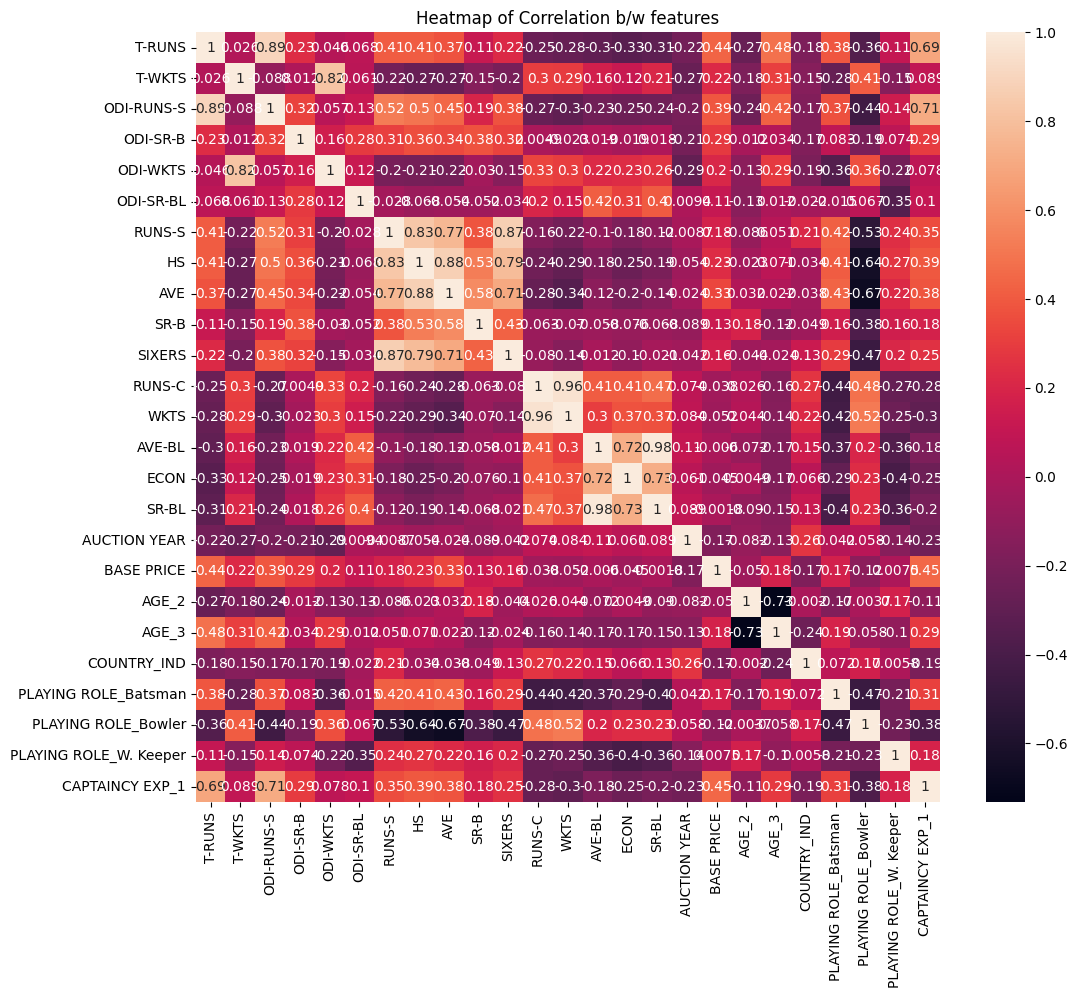

Removing high VIF features: ['T-RUNS', 'ODI-RUNS-S', 'ODI-SR-B', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR']
                            OLS Regression Results                            
Dep. Variable:             SOLD PRICE   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     5.531
Date:                Sat, 02 May 2026   Prob (F-statistic):           1.64e-08
Time:                        21:52:30   Log-Likelihood:                -1450.4
No. Observations:                 104   AIC:                             2941.
Df Residuals:                      84   BIC:                             2994.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                             coef    std er

<Figure size 800x600 with 0 Axes>

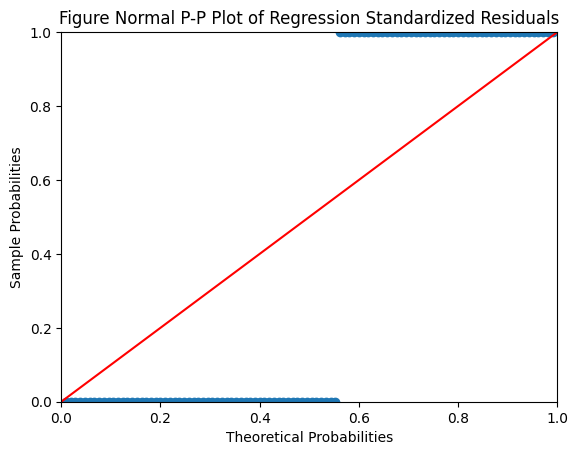

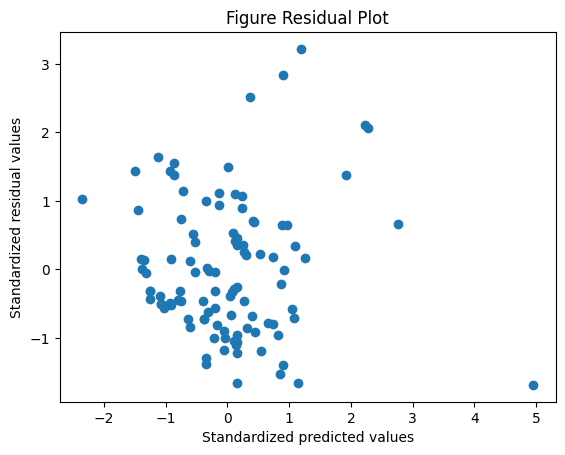

Number of variables: 9 and number of observations: 104
Cutoff for leverage value: 0.288


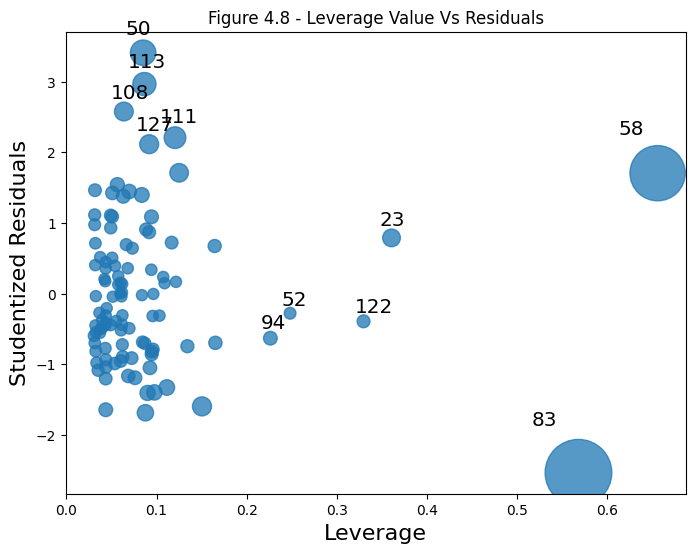

    Sl.NO.      PLAYER NAME  AGE COUNTRY  TEAM PLAYING ROLE  T-RUNS  T-WKTS  \
23      24      Flintoff, A    2     ENG   CSK   Allrounder    3845     226   
58      59  Mascarenhas, AD    2     ENG   RR+   Allrounder       0       0   
83      84    Pietersen, KP    2     ENG  RCB+      Batsman    6654       5   

    ODI-RUNS-S  ODI-SR-B  ...    SR-B  SIXERS  RUNS-C  WKTS  AVE-BL  ECON  \
23        3394     88.82  ...  116.98       2     105     2   52.50  9.55   
58         245     95.33  ...  101.37       1     331    19   17.42  7.01   
83        4184     86.76  ...  141.20      30     215     7   30.71  7.41   

    SR-BL  AUCTION YEAR  BASE PRICE  SOLD PRICE  
23  33.00          2009      950000     1550000  
58  14.95          2011      100000      100000  
83  24.86          2009     1350000     1550000  

[3 rows x 26 columns]
276440.0941455314
0.44


In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.regressionplots import influence_plot
import seaborn as sns
from sklearn.metrics import r2_score,mean_squared_error

# 1. Load Data
ipl_auction_df = pd.read_csv('IPL IMB381IPL2013.csv')

print(ipl_auction_df.head(3))

# 3. Data Preprocessing
# ==============================

# Define categorical columns
categorical_features = ["AGE", "COUNTRY", "PLAYING ROLE", "CAPTAINCY EXP"]

# One-hot encoding
ipl_encoded_df = pd.get_dummies(
    ipl_auction_df,
    columns=categorical_features,
    drop_first=True
)

# Drop unwanted columns
cols_to_drop = ["PLAYER NAME", "TEAM", "Sl.NO."]
ipl_encoded_df = ipl_encoded_df.drop(columns=cols_to_drop, errors="ignore")

# Convert boolean to int
bool_cols = ipl_encoded_df.select_dtypes(include='bool').columns
ipl_encoded_df[bool_cols] = ipl_encoded_df[bool_cols].astype(int)

ipl_encoded_df.columns

# 3. Initial Model Building (Model 1)
Y = ipl_encoded_df["SOLD PRICE"]
X = ipl_encoded_df.drop(columns=["SOLD PRICE"])

# Add constant
X = sm.add_constant(X)

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, train_size=0.8, random_state=42)

ipl_model_1 = sm.OLS(train_Y, train_X).fit()
print(ipl_model_1.summary2())

# 7. VIF Function
# ==============================
def get_vif(df):
    vif_factors = pd.DataFrame()
    vif_factors["column"] = df.columns
    vif_factors["VIF"] = [
        variance_inflation_factor(df.values, i)
        for i in range(df.shape[1])
    ]
    return vif_factors

# Calculate VIF (excluding constant)
vif_factors = get_vif(train_X.drop(columns=["const"]))
print(vif_factors.sort_values(by="VIF", ascending=False))

# Identify columns with high VIF (greater than 4)
cols_lav_vif = vif_factors[vif_factors['VIF'] > 4]["column"]

# Plot Heatmap of Correlation
plt.figure(figsize=(12, 10))
sns.heatmap(X[cols_lav_vif].corr(), annot=True)
plt.title("Heatmap of Correlation b/w features")
plt.show()

# 8. Remove High VIF Features (>10)
# ==============================
high_vif_features = vif_factors[vif_factors["VIF"] > 10]["column"].tolist()

print("Removing high VIF features:", high_vif_features)

X_reduced = train_X.drop(columns=high_vif_features)

# Rebuild model
model_2 = sm.OLS(train_Y, X_reduced).fit()
print(model_2.summary())

# 9. Remove Insignificant Variables (p > 0.05)
# ==============================
significant_vars = model_2.pvalues[model_2.pvalues < 0.1].index
print("Significant variables:", significant_vars)

train_X_final = X_reduced[significant_vars]

# Add constant if removed
if "const" not in train_X_final.columns:
    train_X_final = sm.add_constant(train_X_final)

ipl_model_3 = sm.OLS(train_Y, train_X_final).fit()
print(ipl_model_3.summary())

test_X_final = test_X[train_X_final.columns]

pred_Y = ipl_model_3.predict(test_X_final)

# ==============================
# Diagnostic Plots
# ==============================

def draw_pp_plot(model, title):
    probplot = sm.ProbPlot(model.resid)
    plt.figure(figsize=(8, 6))
    probplot.ppplot(line='45')
    plt.title(title)
    plt.show()


draw_pp_plot(ipl_model_3, 
             "Figure Normal P-P Plot of Regression Standardized Residuals")


def get_standardized_values(vals):
    return (vals - vals.mean()) / vals.std()


def plot_resid_fitted(fitted, resid, title):
    plt.scatter(
        get_standardized_values(fitted),
        get_standardized_values(resid)
    )
    plt.title(title)
    plt.xlabel("Standardized predicted values")
    plt.ylabel("Standardized residual values")
    plt.show()


plot_resid_fitted(
    ipl_model_3.fittedvalues,
    ipl_model_3.resid,
    "Figure Residual Plot"
)


# ==============================
# Leverage
# ==============================

k = train_X_final.shape[1]
n = train_X_final.shape[0]

print("Number of variables:", k, "and number of observations:", n)

leverage_cutoff = 3 * ((k + 1) / n)
print("Cutoff for leverage value:", round(leverage_cutoff, 3))


from statsmodels.graphics.regressionplots import influence_plot

fig, ax = plt.subplots(figsize=(8, 6))
influence_plot(ipl_model_3, ax=ax)
plt.title("Figure 4.8 - Leverage Value Vs Residuals")
plt.show()


print(ipl_auction_df[ipl_auction_df.index.isin([23, 58, 83])])


# ==============================
# Prediction
# ==============================

pred_Y = ipl_model_3.predict(test_X[train_X_final.columns])


from sklearn import metrics

print(np.sqrt(metrics.mean_squared_error(test_Y, pred_Y)))

print(np.round(metrics.r2_score(test_Y, pred_Y), 2))